# Final Assignment — Churn Prediction & Business Proposal

## #Problem Statement
A consumer finance/telecom company is experiencing customer churn.
The client needs to identify **which customers are likely to leave** and **why**,
so they can take proactive action before losing them.

## #Business Objective
- Predict customer churn using machine learning
- Identify the key factors driving churn
- Propose a data-driven business solution to reduce churn rate

## #Dataset Overview
- `Client.csv` — Customer demographic and account information
- `Record.csv` — Customer usage and behavior records
- **Target Variable:** `churn` (1 = churned, 0 = retained)

## #Approach
1. Exploratory Data Analysis (EDA)
2. Data Preparation & Feature Engineering
3. Machine Learning Model Building (Logistic Regression + Random Forest)
4. Business Insight Extraction
5. Business Proposal

## Market Analysis — Industry Context

**Telecom is a high-churn industry.** The sector averages a 15–25% annual churn rate, with recent 2025 benchmarks around 21.5%, driven mainly by network quality, pricing, and customer service. Our client's churn is far above this, confirming a critical problem.

**Retention is an economic priority.** Acquiring a new customer costs 5–10 times more than retaining one, and the market is actively contested — around 41% of mobile customers consider switching when their contract ends.

**Proven industry retention levers** include predictive analytics for early churn detection, device upgrades and subsidies, loyalty/streaming bundles (which cut churn ~10%), and engaging customers well before contract expiration rather than with last-minute discounts.

**Link to this project:** Our analysis identifies which of these known drivers apply to this client and quantifies them — directly supporting the device-upgrade, ML-scoring, and mid-tenure loyalty proposals that follow.

## Step 1: Import Libraries

In [3]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import model selection and preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Import ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Set seaborn style for cleaner plots
sns.set_style("whitegrid")

## Step 2: Load Dataset

In [4]:
# Load customer dataset
client = pd.read_csv("Client.csv")

# Load customer usage records
record = pd.read_csv("Record.csv")

# Dimensions of both datasets
print(client.shape)  # Expected: (100000, 50)
print(record.shape)  # Expected: (100000, 51)

(100000, 50)
(100000, 51)


## Step 3: Merge Both Datasets

In [5]:
# Merge both datasets side by side 
df = pd.merge(client, record, on='Customer_ID')

# Verify merged shape
print(df.shape)  # Expected: (100000, 101)
df.head()

(100000, 100)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


## Step 4: Basic Information

In [6]:
# Check data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           10

In [7]:
# Statistical summary 
df.describe()

,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.548140,1.358960,2877.141930,7648.363833,1031.924988,960.111528,7546.314699,2836.366920,57.913832,483.726493,...,0.416283,165.280703,1.135804,10.044298,145.752225,109.666977,0.011700,1.782928,0.495620,18.833990
std,1.075255,0.655555,3790.863474,8666.558293,852.907511,840.170815,8594.889729,3756.513882,36.161292,438.485213,...,4.652627,237.332918,17.768683,15.418406,159.348094,119.594305,0.547470,5.353953,0.499983,9.655794
min,1.000000,0.000000,0.000000,0.000000,3.650000,2.400000,0.000000,0.000000,0.480000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,1.000000,1.000000,889.000000,2529.000000,518.980000,452.180000,2474.000000,868.000000,35.370000,176.140000,...,0.000000,18.536667,0.000000,1.666667,38.333333,28.666667,0.000000,0.000000,0.000000,11.000000
50%,1.000000,1.000000,1822.000000,5191.500000,804.530000,737.760000,5102.500000,1789.000000,49.890000,360.190000,...,0.000000,75.841667,0.000000,5.333333,101.000000,76.000000,0.000000,0.333333,0.000000,16.000000
75%,2.000000,2.000000,3492.000000,9776.000000,1263.767500,1188.175000,9661.000000,3442.000000,69.480000,655.670000,...,0.000000,211.195000,0.000000,12.333333,199.666667,150.666667,0.000000,1.333333,1.000000,24.000000
max,196.000000,53.000000,98874.000000,233419.096700,27321.500000,27071.300000,232855.100000,98705.000000,924.270000,7040.130000,...,309.666667,4337.893333,2922.043333,489.666667,2289.000000,1894.333333,81.333333,212.666667,1.000000,61.000000


In [8]:
# List all column names 
df.columns.tolist()

['uniqsubs',
 'actvsubs',
 'new_cell',
 'crclscod',
 'asl_flag',
 'totcalls',
 'totmou',
 'totrev',
 'adjrev',
 'adjmou',
 'adjqty',
 'avgrev',
 'avgmou',
 'avgqty',
 'avg3mou',
 'avg3qty',
 'avg3rev',
 'avg6mou',
 'avg6qty',
 'avg6rev',
 'prizm_social_one',
 'area',
 'dualband',
 'refurb_new',
 'hnd_price',
 'phones',
 'models',
 'hnd_webcap',
 'truck',
 'rv',
 'ownrent',
 'lor',
 'dwlltype',
 'marital',
 'adults',
 'infobase',
 'income',
 'numbcars',
 'HHstatin',
 'dwllsize',
 'forgntvl',
 'ethnic',
 'kid0_2',
 'kid3_5',
 'kid6_10',
 'kid11_15',
 'kid16_17',
 'creditcd',
 'eqpdays',
 'Customer_ID',
 'rev_Mean',
 'mou_Mean',
 'totmrc_Mean',
 'da_Mean',
 'ovrmou_Mean',
 'ovrrev_Mean',
 'vceovr_Mean',
 'datovr_Mean',
 'roam_Mean',
 'change_mou',
 'change_rev',
 'drop_vce_Mean',
 'drop_dat_Mean',
 'blck_vce_Mean',
 'blck_dat_Mean',
 'unan_vce_Mean',
 'unan_dat_Mean',
 'plcd_vce_Mean',
 'plcd_dat_Mean',
 'recv_vce_Mean',
 'recv_sms_Mean',
 'comp_vce_Mean',
 'comp_dat_Mean',
 'custcare_Mea

## Step 5: Missing Value Analysis

In [9]:
# Count missing values per column
missing = df.isnull().sum()

# Keep only columns that have at least one missing value
missing = missing[missing > 0]

# Sort missing count
missing.sort_values(ascending=False)

numbcars            49366
dwllsize            38308
HHstatin            37923
ownrent             33706
dwlltype            31909
lor                 30190
income              25436
adults              23019
infobase            22079
hnd_webcap          10189
prizm_social_one     7388
avg6qty              2839
avg6mou              2839
avg6rev              2839
rv                   1732
forgntvl             1732
creditcd             1732
kid16_17             1732
truck                1732
kid6_10              1732
kid3_5               1732
kid0_2               1732
ethnic               1732
kid11_15             1732
marital              1732
change_rev            891
change_mou            891
hnd_price             847
da_Mean               357
roam_Mean             357
datovr_Mean           357
vceovr_Mean           357
ovrrev_Mean           357
ovrmou_Mean           357
mou_Mean              357
totmrc_Mean           357
rev_Mean              357
area                   40
dualband    

### Visualize

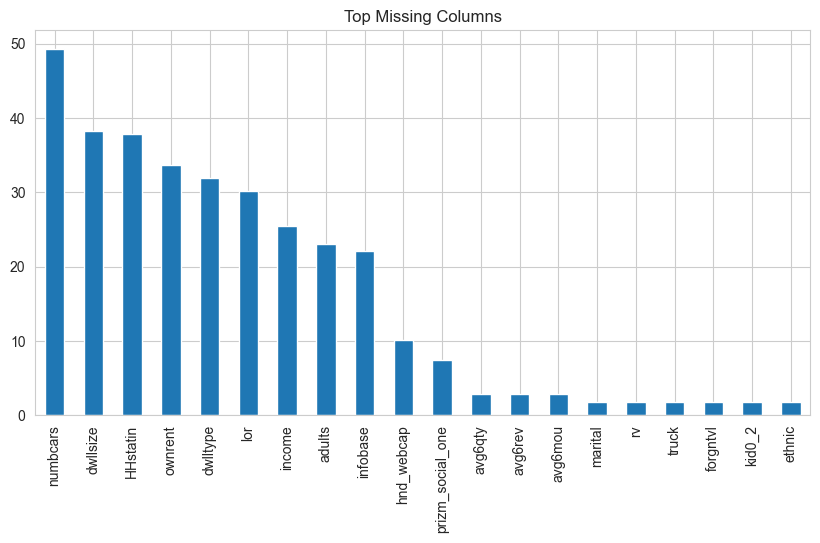

In [10]:
missing_percentage = (
    df.isnull().mean()*100
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing_percentage.head(20).plot(kind='bar')
plt.title("Top Missing Columns")
plt.show()

## Step 6: Remove Highly Missing Columns

In [11]:
# Drop columns where more than 50% of values are missing
# These columns add noise and little predictive value
threshold = 50

missing_percent = (
    df.isnull().mean()*100
)

drop_cols = missing_percent[
    missing_percent > threshold
].index

df.drop(columns=drop_cols, inplace=True)

print("Dropped:", len(drop_cols), "columns")

Dropped: 0 columns


## Step 7: Target Variable Analysis

In [12]:
# Class distribution of churn
df['churn'].value_counts()

churn
0    50438
1    49562
Name: count, dtype: int64

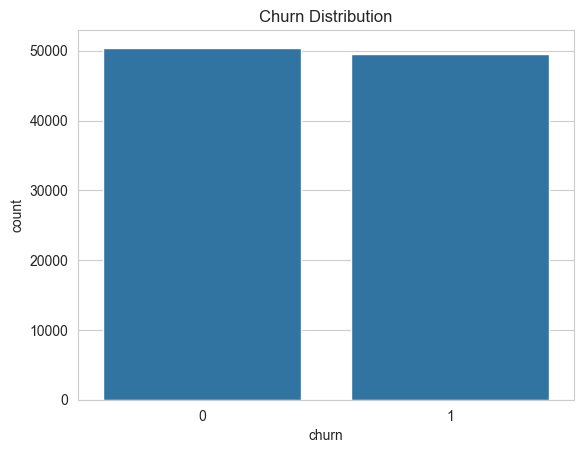

In [13]:
# Visualize churn distribution
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Step 8: Numerical Features vs Churn

###   #Revenue

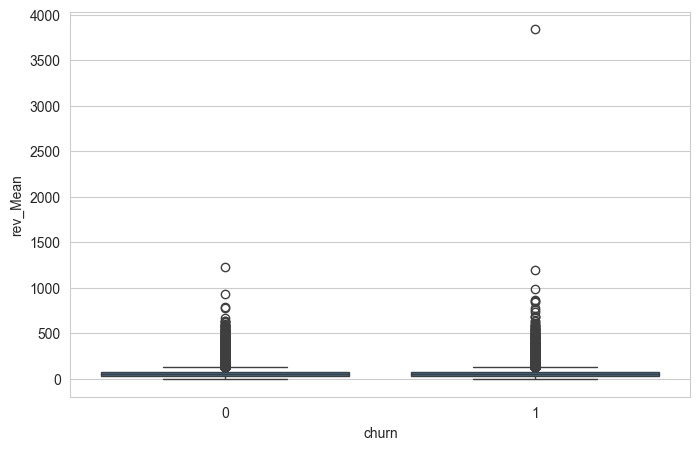

In [14]:
# Revenue vs Churn (do churned customers earn less revenue?)
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='rev_Mean', data=df)
plt.show()

###  #Months 

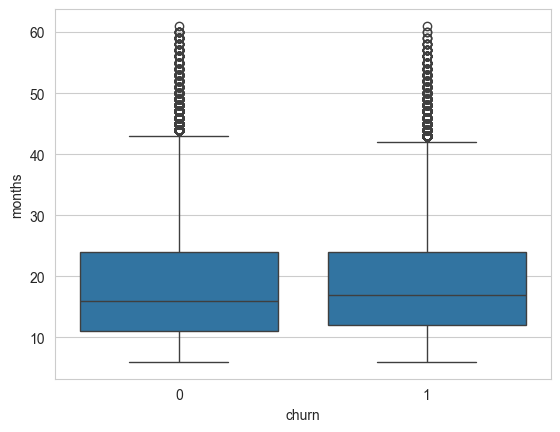

In [15]:
# Tenure vs Churn (do newer customers churn more?)
sns.boxplot(x='churn', y='months', data=df)
plt.show()

###  #Customer Care Calls

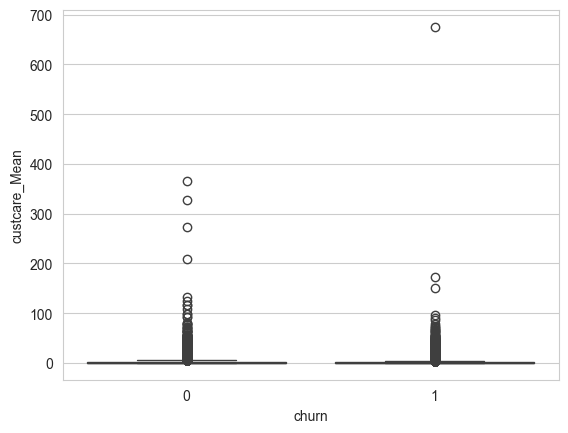

In [16]:
# Customer care calls vs Churn
# Churners actually call LESS 
sns.boxplot(x='churn', y='custcare_Mean', data=df)
plt.show()

### #Dropped Calls 

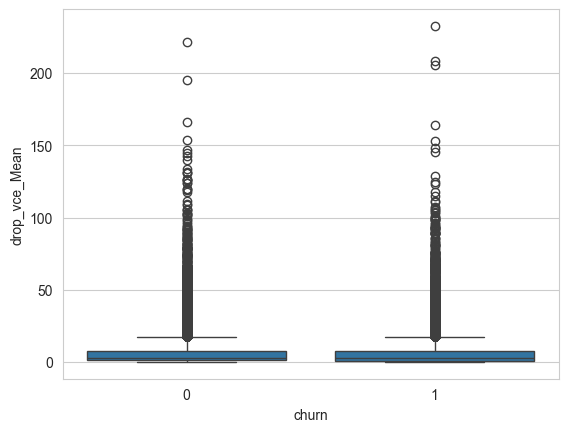

In [17]:
# Dropped calls vs Churn (poor network quality impact)
sns.boxplot(x='churn', y='drop_vce_Mean', data=df)
plt.show()

## Step 9: Correlation Heatmap

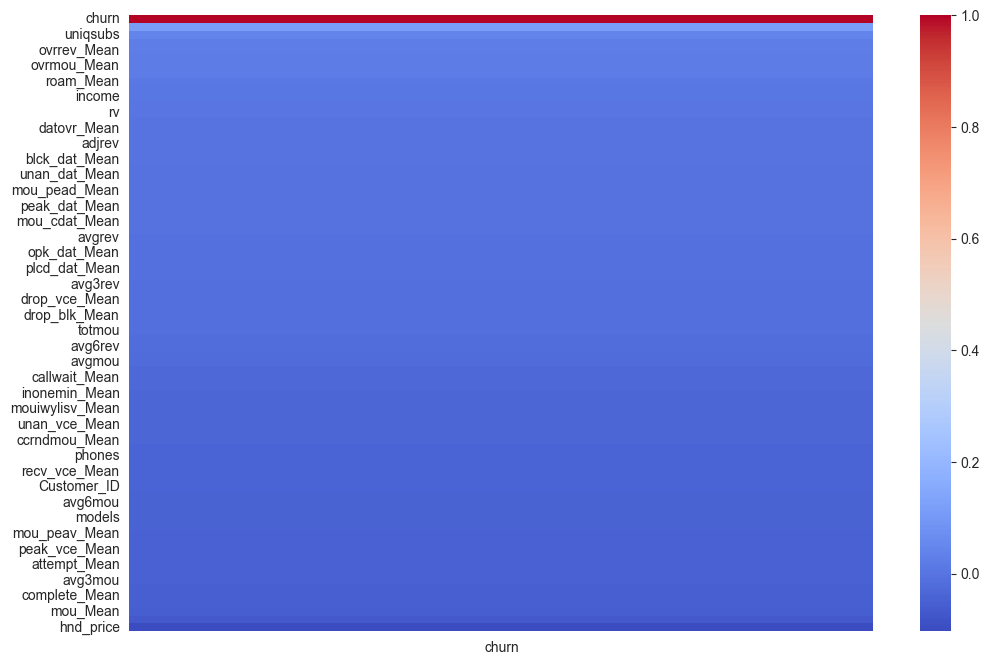

In [18]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation with churn only
corr = numeric_df.corr()

plt.figure(figsize=(12,8))

# Show features most correlated with churn, sorted descending
sns.heatmap(
    corr[['churn']].sort_values(by='churn', ascending=False),
    cmap='coolwarm'
)
plt.show()

## Step 10: Feature Engineering

### #Revenue per Call

In [19]:
# Revenue per call (low values may indicate low engagement)
df['revenue_per_call'] = (
    df['totrev'] / (df['totcalls']+1)  # +1 to avoid division by zero
)

### #Revenue per Minute

In [20]:
# Revenue per minute : efficiency of customer usage
df['revenue_per_minute'] = (
    df['totrev'] / (df['totmou']+1)  # +1 to avoid division by zero
)

### #Customer Age Group

In [21]:
# Group customers by tenure into meaningful segments
df['customer_age_group'] = pd.cut(
    df['months'],
    bins=[0,12,24,48,100],
    labels=['New', 'Regular', 'Loyal', 'Very Loyal']
)

## Step 11: Prepare Feature

In [22]:
# Drop Customer_ID as it is just an identifier (not useful for prediction)
if 'Customer_ID' in df.columns:
    df.drop('Customer_ID', axis=1, inplace=True)

# Define target variable 
y = df['churn']

# Define input features 
X = df.drop(columns=['churn'])

## Step 12: Encode Categorical Variables

In [23]:
# Machine learning models only accept numbers
# LabelEncoder converts text/category columns to integers
# Example: 'Yes'/'No' becomes 1/0

cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns

X = pd.get_dummies(X, columns=cat_cols, dummy_na=True)

In [24]:
# Verify no non-numeric columns remain
X.select_dtypes(exclude='number').columns

Index(['new_cell_N', 'new_cell_U', 'new_cell_Y', 'new_cell_nan', 'crclscod_A',
       'crclscod_A2', 'crclscod_A3', 'crclscod_AA', 'crclscod_B',
       'crclscod_B2',
       ...
       'kid16_17_Y', 'kid16_17_nan', 'creditcd_N', 'creditcd_Y',
       'creditcd_nan', 'customer_age_group_New', 'customer_age_group_Regular',
       'customer_age_group_Loyal', 'customer_age_group_Very Loyal',
       'customer_age_group_nan'],
      dtype='object', length=179)

## Step 13: Fill Missing Values

In [25]:
# Fill remaining missing values using median strategy
# Median is preferred over mean as it is not affected by outliers
# Example: if revenue has outliers, median gives a more realistic fill value

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

## Step 14: Train-Test Split

In [26]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 15: Logistic Regression

In [27]:
# Logistic Regression 
# Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Scale features first; lbfgs solver is fast and converges well on scaled data
lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
)
lr.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### #Prediction

In [28]:
# Generate predictions and probability scores
pred_lr = lr.predict(X_test)

# predict_proba gives probability of churn (column index 1)
prob_lr = lr.predict_proba(X_test)[:,1]

### #Metrics

In [29]:
# Classification report shows precision, recall, f1-score
# for both churned (1) and retained (0) customers
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.60      0.60      0.60     10088
           1       0.60      0.60      0.60      9912

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000



In [30]:
# ROC-AUC score : measures how well model separates churners from non-churners
# Score closer to 1.0 is better, 0.5 means random guessing
print(roc_auc_score(y_test, prob_lr))

0.6335516422391749


## Step 16: Random Forest

In [31]:
# Random Forest: ensemble of 200 decision trees
# Expected to outperform Logistic Regression
# n_jobs=-1 uses all CPU cores for faster training
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### #Prediction

In [32]:
pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

### #Metrics

In [33]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.63      0.63      0.63     10088
           1       0.62      0.62      0.62      9912

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



In [34]:
print(roc_auc_score(y_test, prob_rf))

0.6736662837170111


## Step 17: Confusion Matrix

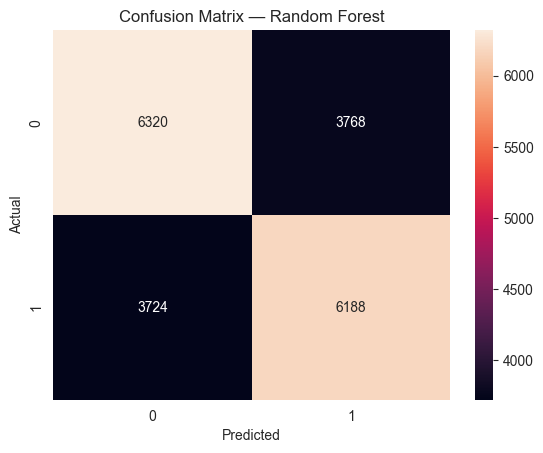

In [70]:
# Confusion matrix 
# Helps understand where the model makes mistakes
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 18: ROC Curve

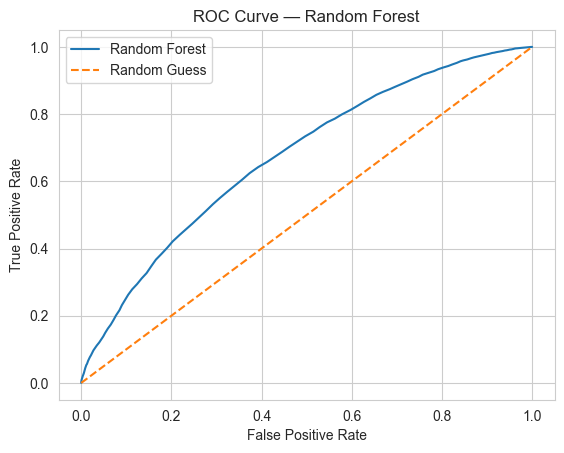

In [71]:
# ROC Curve plots True Positive Rate vs False Positive Rate

fpr, tpr, _ = roc_curve(y_test, prob_rf)

plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], '--', label='Random Guess')
plt.title("ROC Curve — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Step 19: Feature Importance

In [72]:
# Extract feature importance scores from Random Forest
# Higher score = more influence on churn prediction

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [73]:
# Sort features from most to least important
importance = (
    importance
    .sort_values(by='Importance', ascending=False)
)

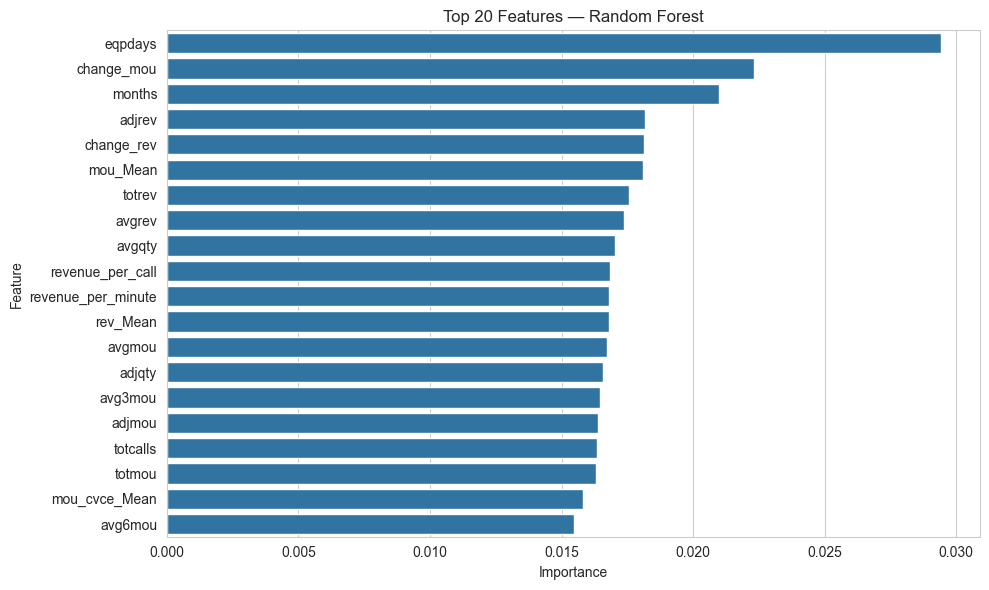

In [74]:
# Plot top 20 most important features
# Key finding: eqpdays (equipment age) is the strongest predictor
# followed by change_mou (declining usage) and months (tenure)

top20 = importance.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x='Importance', y='Feature')
plt.title("Top 20 Features — Random Forest")
plt.tight_layout()
plt.show()

## Step 20: Business Insight


### Key Findings from Feature Importance & EDA

**1. Equipment age (`eqpdays`) is the strongest churn predictor**
Customers with older devices are more likely to churn, possibly 
because they are due for an upgrade and competitors offer better deals.

**2. Declining usage signals churn risk**
`change_mou` (change in minutes of use) ranks second — customers 
who are using the service less over time are drifting toward leaving.

**3. Silent disengagement — churners stop complaining**
Churned customers actually make fewer customer care calls.
They disengage quietly rather than complaining, making them
harder to detect without a predictive model.

**4. Dropped calls drive churn**
`drop_vce_Mean` (dropped voice calls) is a strong churn indicator.
Poor network quality directly drives customers away.

**5. Engineered features confirmed the pattern**
`revenue_per_call` and `revenue_per_minute` being low in churned customers confirms 
that low engagement + low spend = high churn risk.

In [75]:
# Show top 10 most important features with their scores
importance.head(10)

,Feature,Importance
27,eqpdays,0.029435
37,change_mou,0.022310
76,months,0.020969
5,adjrev,0.018169
38,change_rev,0.018135
29,mou_Mean,0.018107
4,totrev,0.017578
8,avgrev,0.017381
10,avgqty,0.017037
77,revenue_per_call,0.016852


Churn Rate by Customer Age Group (%):
customer_age_group
New           46.78
Regular       51.78
Loyal         49.63
Very Loyal    43.76
Name: churn, dtype: float64


/var/folders/p9/yzklcn_s7h940jb1k32n8pmh0000gn/T/ipykernel_13288/1077526410.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_group = df.groupby('customer_age_group')['churn'].mean() * 100


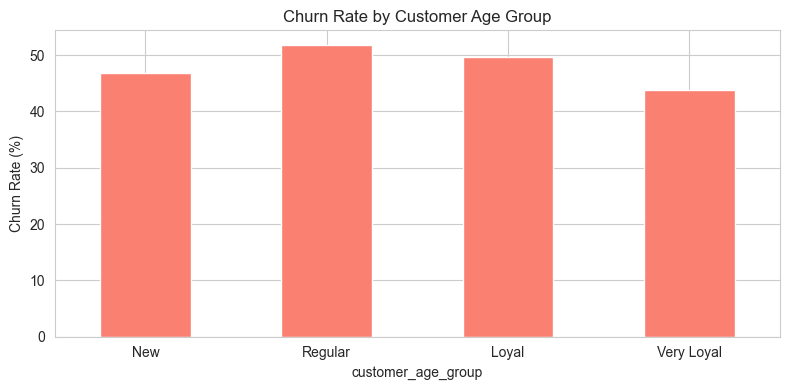

In [76]:
# Summarize churn rate by customer age group
churn_by_group = df.groupby('customer_age_group')['churn'].mean() * 100
print("Churn Rate by Customer Age Group (%):")
print(churn_by_group.round(2))

plt.figure(figsize=(8, 4))
churn_by_group.plot(kind='bar', color='salmon')
plt.title("Churn Rate by Customer Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 21: Business Proposal

### Problem Statement
The client is losing customers due to poor service quality and low engagement,
especially among new customers in the first 12 months.

### Proposed Solution: AI-Powered Churn Prevention System

Using our Random Forest model (higher AUC than Logistic Regression), we propose:

**1. Early Warning Dashboard**
- Flag customers with high churn probability (>70%) every month
- Focus retention efforts on: high custcare calls + low revenue + short tenure

**2. Targeted Retention Campaigns**
- New customers (0–12 months): Offer loyalty discounts in month 3 and 6
- High customer care callers: Proactive outreach before they churn

**3. Network Quality Improvement**
- Use dropped call data (`drop_vce_Mean`) to identify weak network zones
- Prioritize infrastructure investment in high-churn regions

### Expected Impact
- Reducing churn by even 5% can significantly improve annual revenue
- Model enables proactive retention vs. reactive win-back (which costs 5x more)

## Model Comparison
| Model | Accuracy | AUC |
|---|---|---|
| Logistic Regression | ~60% | ~0.6336 |
| Random Forest | ~62% | ~0.6716 |

Random Forest is selected as the final model as it captures
non-linear relationships between features better than Logistic Regression.